<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/modal_training_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

import pickle

with open('/content/drive/MyDrive/train_test_val_data/X_train_DT.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('/content/drive/MyDrive/train_test_val_data/X_test_DT.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('/content/drive/MyDrive/train_test_val_data/y_train_DT.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('/content/drive/MyDrive/train_test_val_data/y_test_DT.pkl', 'rb') as f:
    y_test = pickle.load(f)

In [4]:
from sklearn.tree import DecisionTreeClassifier

In [5]:
model = DecisionTreeClassifier(random_state=42)

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [7]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
train_preds = model.predict(X_train)
train_preds

array(['No', 'No', 'Yes', ..., 'Yes', 'No', 'No'], dtype=object)

In [9]:
train_acc=accuracy_score(y_train, train_preds)
train_acc

1.0

We can make predictions and compute accuracy in one step using model.score

In [10]:
from sklearn.dummy import DummyClassifier

In [11]:
dummy_model = DummyClassifier(strategy='most_frequent')

In [12]:
dummy_model.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [13]:
dummy_model.score(X_test, y_test)

0.8616780045351474

In [14]:
model.score(X_test,y_test)

0.782312925170068

In [15]:
model.feature_importances_

array([0.06142022, 0.07909049, 0.00318767, 0.00248405, 0.        ,
       0.04611307, 0.04041497, 0.06139251, 0.01459737, 0.01256594,
       0.01279442, 0.1322524 , 0.04804398, 0.00321629, 0.        ,
       0.00456943, 0.02515241, 0.        , 0.01567623, 0.04777599,
       0.01444828, 0.0174269 , 0.01378193, 0.04218581, 0.04823414,
       0.00706428, 0.02548073, 0.04423722, 0.        , 0.01298135,
       0.00456943, 0.        , 0.        , 0.00456943, 0.        ,
       0.        , 0.01012305, 0.        , 0.0015993 , 0.00606763,
       0.00971005, 0.00456943, 0.00628297, 0.        , 0.00164139,
       0.        , 0.        , 0.        , 0.00959581, 0.        ,
       0.        , 0.        , 0.        , 0.02999334, 0.        ,
       0.        , 0.07469007])

In [16]:
imp_feature_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
imp_feature_df.head(15)

,feature,importance
11,MonthlyIncome,0.132252
1,DailyRate,0.079090
56,OverTime_Yes,0.074690
0,Age,0.061420
7,HourlyRate,0.061393
24,YearsSinceLastPromotion,0.048234
12,MonthlyRate,0.048044
19,TotalWorkingYears,0.047776
5,EmployeeNumber,0.046113
27,job_change_frequency,0.044237


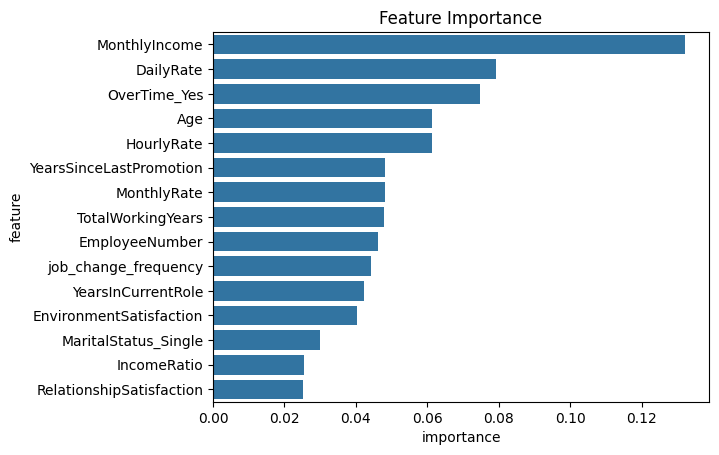

In [17]:
plt.title('Feature Importance')
sns.barplot(data=imp_feature_df.head(15), x='importance', y='feature');

In [18]:
model.get_depth()

17

## Hyperparameter tuining

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer,f1_score

In [20]:
parameter_grid={
    'max_depth':[3, 4, 5, 6, 7, 8, 10],
    'min_samples_split':[2, 10, 20, 50],
     'min_samples_leaf':  [1, 5, 10, 20],
      'criterion':['gini', 'entropy'],
       'class_weight':['balanced', None],
       'max_features':[None, 'sqrt',0.5]
}

clf_model=DecisionTreeClassifier(ccp_alpha=0.0,random_state=42)

gride_prepruning_model=GridSearchCV(estimator=clf_model,param_grid=parameter_grid,cv=5,scoring=make_scorer(f1_score, pos_label='Yes'))
gride_prepruning_model.fit(X_train,y_train)



GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 10],
                         'max_features': [None, 'sqrt', 0.5],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 10, 20, 50]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=Yes))

In [21]:
gride_prepruning_model.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 4,
 'max_features': None,
 'min_samples_leaf': 10,
 'min_samples_split': 50}

In [22]:
model_first_hyper_para=DecisionTreeClassifier(
    class_weight='balanced',
    criterion='entropy',
    max_depth=4,
    max_features=None,
    min_samples_leaf=10,
    min_samples_split=50

)

In [23]:
model_first_hyper_para.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=4, min_samples_leaf=10, min_samples_split=50)

In [24]:
train_pradiction=model_first_hyper_para.predict(X_train)


In [25]:
train_pradiction

array(['No', 'No', 'Yes', ..., 'Yes', 'Yes', 'Yes'], dtype=object)

In [26]:
accuracy_score(y_train,train_pradiction)

0.7210884353741497

In [27]:
model_first_hyper_para.score(X_test,y_test)

0.671201814058957

In [28]:
test_prad=model_first_hyper_para.predict(X_test)

## Model Evaluation

In [29]:
from sklearn.metrics import confusion_matrix

In [30]:
cm=confusion_matrix(y_test,test_prad)
cm

array([[255, 125],
       [ 20,  41]])

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_prad,
      target_names=['Stayed', 'Left']))

              precision    recall  f1-score   support

      Stayed       0.93      0.67      0.78       380
        Left       0.25      0.67      0.36        61

    accuracy                           0.67       441
   macro avg       0.59      0.67      0.57       441
weighted avg       0.83      0.67      0.72       441



In [32]:
sorted(np.unique(y_test))

['No', 'Yes']

The model performed as expected because it is useful for identifying who will stay, but it is unreliable for identifying who will leave.

We cannot make it much more precise, and even if we could, the model may still not be as good or accurate as expected because the target class is highly imbalanced (approximately 6:1). We need more data or a different approach, such as Random Forest, SMOTE, or threshold tuning, to improve predictions for the **Left** class.


## Random forest

In [33]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint


In [34]:
param_grid = {
    'n_estimators': randint(100, 150),
    'max_depth': [None, 5, 7, 11, 13, 17],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2'],
    'sampling_strategy': ['auto', 0.3, 0.5, 0.75],
    'replacement': [True, False],
}


In [35]:
cv=StratifiedKFold(n_splits=6,shuffle=True,random_state=42)

In [36]:
random_search = RandomizedSearchCV(
    estimator=BalancedRandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=100,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


In [37]:
#random_search.fit(X_train,y_train)

In [38]:
#random_search.best_params_

In [39]:
rf_model =BalancedRandomForestClassifier(
    n_estimators=121,
    max_depth=5,
    max_features='log2',
    min_samples_split=4,
    min_samples_leaf=19,
    replacement=False,
    bootstrap=True,
    oob_score=True,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

In [40]:
rf_model.fit(X_train,y_train)

BalancedRandomForestClassifier(bootstrap=True, max_depth=5, max_features='log2',
                               min_samples_leaf=19, min_samples_split=4,
                               n_estimators=121, n_jobs=-1, oob_score=True,
                               random_state=42, replacement=False,
                               sampling_strategy='auto')

In [41]:
rf_train_pradiction=rf_model.predict(X_train)

In [42]:
rf_train_acc=accuracy_score(y_train,rf_train_pradiction)

In [43]:
rf_train_acc

0.7881438289601554

In [44]:
rf_model.score(X_test,y_test)

0.7709750566893424

In [53]:
rf_test_pradiction=rf_model.predict(X_test)

In [65]:
rf_test_pradiction_proba=rf_model.predict_proba(X_test)
rf_test_pradiction_proba


array([[0.55260339, 0.44739661],
       [0.64945935, 0.35054065],
       [0.31369787, 0.68630213],
       [0.65068416, 0.34931584],
       [0.5969089 , 0.4030911 ],
       [0.45499225, 0.54500775],
       [0.56378979, 0.43621021],
       [0.54059486, 0.45940514],
       [0.62565839, 0.37434161],
       [0.37823306, 0.62176694],
       [0.39575835, 0.60424165],
       [0.63242661, 0.36757339],
       [0.54136667, 0.45863333],
       [0.50253693, 0.49746307],
       [0.49259642, 0.50740358],
       [0.54705515, 0.45294485],
       [0.39182146, 0.60817854],
       [0.56692396, 0.43307604],
       [0.5885691 , 0.4114309 ],
       [0.67913777, 0.32086223],
       [0.47737473, 0.52262527],
       [0.71267394, 0.28732606],
       [0.56557482, 0.43442518],
       [0.56504652, 0.43495348],
       [0.62750419, 0.37249581],
       [0.6871823 , 0.3128177 ],
       [0.26169489, 0.73830511],
       [0.66230871, 0.33769129],
       [0.58533562, 0.41466438],
       [0.68510856, 0.31489144],
       [0.

In [64]:
rf_test_pradiction_proba_positive=rf_test_pradiction_proba[: ,1]
rf_test_pradiction_proba_positive

array([0.44739661, 0.35054065, 0.68630213, 0.34931584, 0.4030911 ,
       0.54500775, 0.43621021, 0.45940514, 0.37434161, 0.62176694,
       0.60424165, 0.36757339, 0.45863333, 0.49746307, 0.50740358,
       0.45294485, 0.60817854, 0.43307604, 0.4114309 , 0.32086223,
       0.52262527, 0.28732606, 0.43442518, 0.43495348, 0.37249581,
       0.3128177 , 0.73830511, 0.33769129, 0.41466438, 0.31489144,
       0.35406386, 0.34769482, 0.27905675, 0.3680938 , 0.45663183,
       0.32089939, 0.28200795, 0.56787198, 0.68359596, 0.37895008,
       0.40161872, 0.38709824, 0.35660603, 0.39264327, 0.76441442,
       0.30211092, 0.58359845, 0.55886758, 0.41935907, 0.83071909,
       0.33194204, 0.48891964, 0.33560119, 0.43572792, 0.45385677,
       0.51747859, 0.52738273, 0.26264268, 0.40373538, 0.40696624,
       0.3198054 , 0.75083561, 0.4124647 , 0.29559463, 0.45767062,
       0.54609881, 0.31820791, 0.43543473, 0.42140273, 0.45642063,
       0.39813384, 0.44359669, 0.44782207, 0.42207543, 0.46730

In [46]:
cm=confusion_matrix(y_test,rf_test_pradiction)
cm


array([[304,  76],
       [ 25,  36]])

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test,rf_test_pradiction ,
      target_names=['Stayed', 'Left']))

              precision    recall  f1-score   support

      Stayed       0.92      0.80      0.86       380
        Left       0.32      0.59      0.42        61

    accuracy                           0.77       441
   macro avg       0.62      0.70      0.64       441
weighted avg       0.84      0.77      0.80       441



In [50]:
#  Threshold tuning for optimal F1 on minority class
# from sklearn.metrics import precision_recall_curve

# # Get probabilities for the positive class
# probs = rf_model.predict_proba(X_test)
# # Find which class is the positive (minority) class
# pos_idx = list(rf_model.classes_).index('Left') if 'Left' in rf_model.classes_ else 1
# pos_probs = probs[:, pos_idx]

# # Find threshold that maximizes F1
# precision, recall, thresholds = precision_recall_curve(y_test, pos_probs, pos_label='Left')
# f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
# best_idx = np.argmax(f1_scores)
# best_thresh = thresholds[best_idx]
# best_f1 = f1_scores[best_idx]

# print(f'Best threshold: {best_thresh:.3f}')
# print(f'Best F1 (Left): {best_f1:.3f}')
# print()

# # Apply optimal threshold
# preds_tuned = (pos_probs >= best_thresh).astype(int)
# # Map back to original labels
# left_label = rf_model.classes_[pos_idx]
# stayed_label = rf_model.classes_[1 - pos_idx]
# preds_tuned_labels = np.where(preds_tuned == 1, left_label, stayed_label)

# print('--- Default threshold (0.5) ---')
# print(classification_report(y_test, rf_test_pradiction, target_names=['Stayed', 'Left']))

# print('--- Tuned threshold ---')
# print(classification_report(y_test, preds_tuned_labels, target_names=['Stayed', 'Left']))


Here since the data is imbalanced roughly with 85:15 ratio we used BalancedRandomForestClassifier . The model is performing good for the majority class(NO) with  precision  0.92  recall
0.80 and f1=0.86 which is not bad .But our model fails to predict good result for Minority class(YES) since its f1 is only 0.42 , now we may try other optimization tecnique like Threshold tuining and other for imporving our model

In [51]:
from sklearn.metrics import precision_recall_curve

In [67]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_test_pradiction_proba_positive,pos_label="Yes")


 Each value in thresholds is the boundary: predict 'Yes' if prob >=      
     threshold. The curve shows how precision and recall trade off across    
     all possible thresholds, so you can pick one that balances them for     
     your use case.

In [69]:
thresholds

array([0.21640062, 0.22727969, 0.23338593, 0.23421307, 0.24180784,
       0.24310823, 0.2476778 , 0.24984616, 0.25281859, 0.25413023,
       0.25432747, 0.26264268, 0.2649548 , 0.2663813 , 0.26959367,
       0.27054562, 0.27343233, 0.27905675, 0.27952454, 0.28128385,
       0.28150472, 0.28200795, 0.28494556, 0.28537332, 0.2859187 ,
       0.28691877, 0.28732606, 0.28894585, 0.28979947, 0.29028194,
       0.29239042, 0.2928497 , 0.29391171, 0.2939765 , 0.29458583,
       0.29559463, 0.2960451 , 0.29760314, 0.29841155, 0.29849483,
       0.29890906, 0.2998104 , 0.29991488, 0.30195484, 0.30211092,
       0.30625579, 0.30737037, 0.30811384, 0.30822791, 0.30890907,
       0.30939278, 0.31061367, 0.31205322, 0.3128177 , 0.31398322,
       0.31489144, 0.31535779, 0.31600969, 0.31625157, 0.31648952,
       0.31701417, 0.31779031, 0.31820791, 0.31882132, 0.31979496,
       0.3198054 , 0.32046997, 0.32086223, 0.32089939, 0.32224313,
       0.32274054, 0.32339657, 0.32508215, 0.32510416, 0.32648

In [72]:
#calculate the f1 for each thresholds
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
f1_scores

array([0.24302789, 0.24351297, 0.244     , 0.24448898, 0.24497992,
       0.24547284, 0.24596774, 0.24646465, 0.24696356, 0.2474645 ,
       0.24796748, 0.2484725 , 0.24897959, 0.24948875, 0.25      ,
       0.25051335, 0.25102881, 0.25154639, 0.25206612, 0.25258799,
       0.24896266, 0.24948025, 0.25      , 0.24634656, 0.24686192,
       0.24737945, 0.24789916, 0.24842105, 0.24894515, 0.24947146,
       0.25      , 0.25053079, 0.25106383, 0.25159915, 0.25213675,
       0.25267666, 0.25321888, 0.25376344, 0.25431034, 0.25485961,
       0.25541126, 0.2516269 , 0.25217391, 0.25272331, 0.25327511,
       0.25382932, 0.25438596, 0.25494505, 0.25550661, 0.25607064,
       0.25221239, 0.25277162, 0.25333333, 0.24944321, 0.25      ,
       0.25055928, 0.25112108, 0.25168539, 0.25225225, 0.25282167,
       0.25339366, 0.25396825, 0.25454545, 0.25512528, 0.25570776,
       0.25629291, 0.25688073, 0.25747126, 0.25806452, 0.25866051,
       0.25925926, 0.25986079, 0.26046512, 0.26107226, 0.26168

In [74]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [78]:
best_idx= np.argmax(f1_scores)

In [76]:
best_threshold = thresholds[np.argmax(f1_scores)]


In [77]:
best_threshold

np.float64(0.49962621410567437)

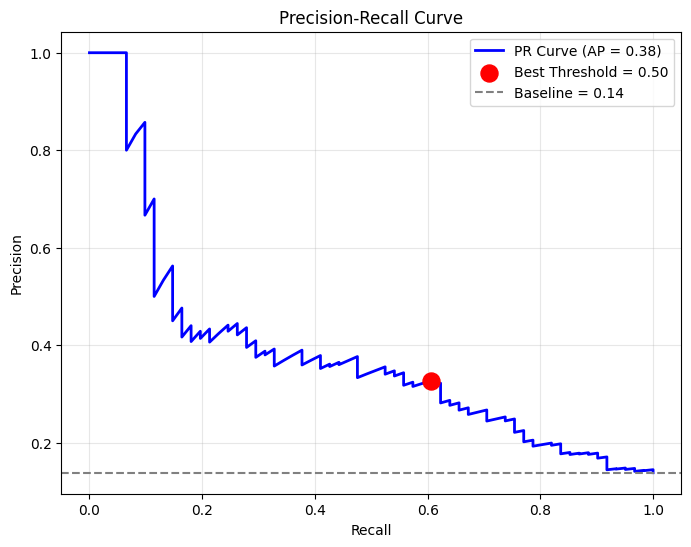

In [82]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2,
         label=f'PR Curve (AP = {average_precision_score(y_test, rf_test_pradiction_proba_positive,pos_label="Yes"):.2f})')
plt.scatter(recall[best_idx], precision[best_idx], color='red', s=150, zorder=5,
            label=f'Best Threshold = {best_threshold:.2f}')
baseline = (y_test == "Yes").mean()

plt.axhline(
    y=baseline,
    color='gray',
    linestyle='--',
    label=f'Baseline = {baseline:.2f}'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [91]:
rf_test_prad_final = (rf_test_pradiction_proba>= best_threshold).astype(int)
rf_test_prad_final = np.where(
    rf_test_pradiction_proba_positive >= best_threshold,
    "Yes",
    "No"
)


In [92]:
cm=confusion_matrix(y_test,rf_test_prad_final)
cm

array([[304,  76],
       [ 24,  37]])

In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test,rf_test_prad_final ,
      target_names=['Stayed', 'Left']))

              precision    recall  f1-score   support

      Stayed       0.93      0.80      0.86       380
        Left       0.33      0.61      0.43        61

    accuracy                           0.77       441
   macro avg       0.63      0.70      0.64       441
weighted avg       0.84      0.77      0.80       441

